Baseline XGBoost Model (Single Split)

Code you just shared

Model: XGBRegressor

Train: All data before 2012

Test: All data in 2012

Target: Weekly_Sales (raw, no log)

Metrics: RMSE, MAE, SMAPE

Output: Strong performance (e.g., RMSE ~ $8k–9k

RMSE : $8,414.79
MAE  : $4,923.27
SMAPE: 66.31%


<Figure size 1200x600 with 0 Axes>

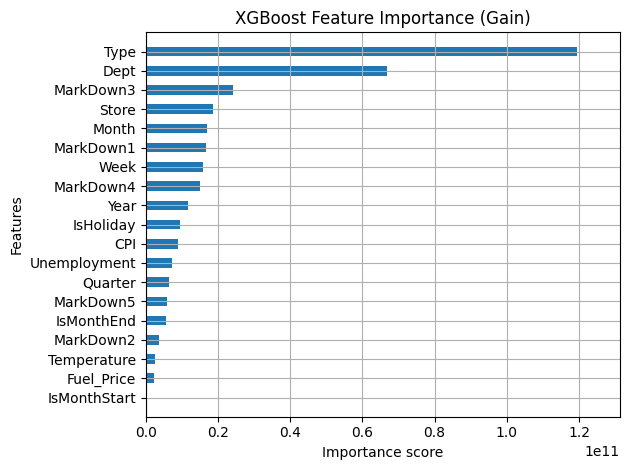


Sample predictions:
        Store  Dept       Date  Weekly_Sales     Predicted     Abs_Error
293204     26    16 2012-01-06       2341.85   6329.434570   3987.584570
293205     10    58 2012-01-06       3230.00   7403.515625   4173.515625
293206     28    91 2012-01-06      85560.10  62494.562500  23065.537500
293207     10    55 2012-01-06      18898.35  17380.634766   1517.715234
293208     16    67 2012-01-06       3309.51   1611.651733   1697.858267
293209     32    26 2012-01-06       3362.44  10564.274414   7201.834414
293210     28    10 2012-01-06      14014.90  23246.240234   9231.340234
293211     11    40 2012-01-06      61342.39  44885.066406  16457.323594
293212     37    22 2012-01-06         64.40   1524.720703   1460.320703
293213     23    52 2012-01-06       1724.71   6695.196289   4970.486289


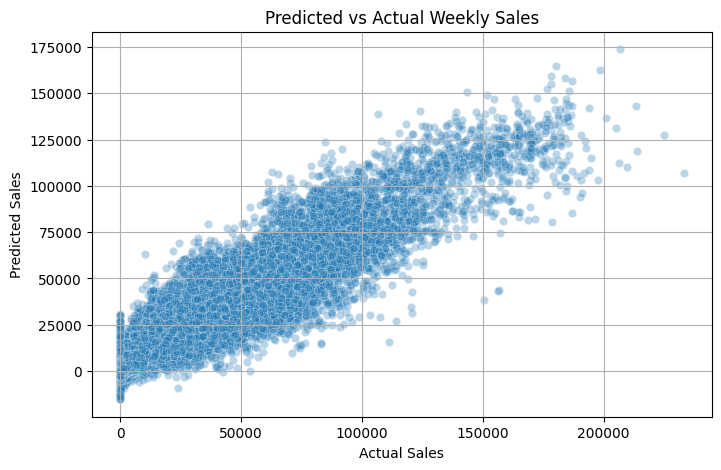

In [37]:
# 1. Imports
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# 2. Load dataset
df = pd.read_csv('/Users/jinenmodi/ImpData/supplychain-genai-optim/data/processed/cleaned_walmart_data.csv', parse_dates=['Date'])

# 3. Clean and sort
df = df[df['Weekly_Sales'] > 0].sort_values('Date').reset_index(drop=True)

# 4. Encode categorical vars (tree-safe)
df['Store'] = df['Store'].astype(int)
df['Dept'] = df['Dept'].astype(int)
df['Type'] = df['Type'].astype('category').cat.codes

# 5. Feature and target setup
features = [
    'Store', 'Dept', 'Type', 'IsHoliday',
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'Year', 'Month', 'Week', 'Day', 'Quarter', 'IsMonthStart', 'IsMonthEnd'
]
target = 'Weekly_Sales'

# 6. Time-based train-test split
train_df = df[df['Date'] < '2012-01-01']
test_df = df[df['Date'] >= '2012-01-01']

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

# 7. Train XGBoost
model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    objective="reg:squarederror"
)
model.fit(X_train, y_train)

# 8. Predictions
y_pred = model.predict(X_test)

# 9. Evaluation
def smape(y_true, y_pred):
    return 100 * np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    smape_val = smape(y_true, y_pred)
    return rmse, mae, smape_val

rmse, mae, smape_val = evaluate(y_test, y_pred)
print(f"RMSE : ${rmse:,.2f}")
print(f"MAE  : ${mae:,.2f}")
print(f"SMAPE: {smape_val:.2f}%")

# 10. Feature importance
plt.figure(figsize=(12, 6))
xgb.plot_importance(model, importance_type='gain', height=0.5, show_values=False)
plt.title("XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.show()

# 11. Sample predictions
sample = test_df[['Store', 'Dept', 'Date', 'Weekly_Sales']].copy()
sample['Predicted'] = y_pred
sample['Abs_Error'] = np.abs(sample['Weekly_Sales'] - sample['Predicted'])

print("\nSample predictions:")
print(sample[['Store', 'Dept', 'Date', 'Weekly_Sales', 'Predicted', 'Abs_Error']].head(10))



# Optional: Scatter plot for diagnostics
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Predicted vs Actual Weekly Sales")
plt.grid(True)
plt.show()


TimeSeriesSplit XGBoost (Cross-Validation)

XGBRegressor again 

Used TimeSeriesSplit(n_splits=5)

Trained on rolling historical windows

Tested on next time chunks

Target: Weekly_Sales again (raw)

Purpose: Validate model generalization over time

Output: Slightly higher RMSE/MAE, but realistic

In [38]:
# 1. Imports
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 2. Load dataset
df = pd.read_csv('/Users/jinenmodi/ImpData/supplychain-genai-optim/data/processed/cleaned_walmart_data.csv', parse_dates=['Date'])

# 3. Preprocess
df = df[df['Weekly_Sales'] > 0].sort_values('Date').reset_index(drop=True)
df['Store'] = df['Store'].astype(int)
df['Dept'] = df['Dept'].astype(int)
df['Type'] = df['Type'].astype('category').cat.codes

# 4. Features and target
features = [
    'Store', 'Dept', 'Type', 'IsHoliday',
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'Year', 'Month', 'Week', 'Day', 'Quarter', 'IsMonthStart', 'IsMonthEnd'
]
target = 'Weekly_Sales'
X = df[features]
y = df[target]

# 5. TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
fold_results = []

# 6. Evaluation functions
def smape(y_true, y_pred):
    return 100 * np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    smape_val = smape(y_true, y_pred)
    return rmse, mae, smape_val

# 7. Loop through folds
fold = 1
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method="hist",
        objective="reg:squarederror"
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse, mae, smape_val = evaluate(y_test, y_pred)
    fold_results.append({'Fold': fold, 'RMSE': rmse, 'MAE': mae, 'SMAPE': smape_val})
    print(f"Fold {fold} - RMSE: ${rmse:,.2f}, MAE: ${mae:,.2f}, SMAPE: {smape_val:.2f}%")
    fold += 1

# 8. Summary
results_df = pd.DataFrame(fold_results)
print("\nCross-Validation Summary:")
print(results_df)

print("\nAverage Metrics:")
print(results_df[['RMSE', 'MAE', 'SMAPE']].mean())


Fold 1 - RMSE: $12,516.40, MAE: $5,619.17, SMAPE: 63.39%
Fold 2 - RMSE: $11,042.10, MAE: $7,343.98, SMAPE: 73.30%
Fold 3 - RMSE: $8,276.37, MAE: $4,520.51, SMAPE: 62.25%
Fold 4 - RMSE: $9,358.72, MAE: $5,159.92, SMAPE: 65.79%
Fold 5 - RMSE: $6,455.79, MAE: $3,843.79, SMAPE: 57.16%

Cross-Validation Summary:
   Fold          RMSE          MAE      SMAPE
0     1  12516.399242  5619.165318  63.391644
1     2  11042.095549  7343.979994  73.301719
2     3   8276.372357  4520.513381  62.250796
3     4   9358.715165  5159.917438  65.786631
4     5   6455.794199  3843.790111  57.162834

Average Metrics:
RMSE     9529.875302
MAE      5297.473248
SMAPE      64.378725
dtype: float64


In [11]:
pip install scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
